In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
import pandas as pd

# 나이, 연봉을 수집하여 전처리(결측치, 이상치, ...) 후 나이순으로 정렬된 데이터셋
customers =[
    [28, 2387], [30, 3271], [29, 3121], [25, 2957], [22, 3321], [22, 2067], [21, 3441], [20, 2487], [27, 3276], [20, 3619], 
    [25, 2906], [26, 2444], [25, 3155], [29, 2247], [25, 3424], [28, 3429], [27, 2704], [30, 3418], [24, 3237], [30, 3201], 
    [27, 2117], [23, 3322], [30, 2229], [26, 3570], [23, 2636], [26, 2648], [29, 2088], [23, 2250], [23, 3400], [30, 3104], 
    [28, 3305], [26, 2476], [28, 3404], [26, 2483], [26, 2147], [41, 7916], [41, 7112], [50, 6993], [35, 6144], [36, 5034], 
    [39, 5410], [36, 7257], [40, 5384], [42, 7733], [48, 6056], [43, 7516], [48, 5465], [46, 6257], [36, 6189], [40, 5470], 
    [42, 6786], [48, 5312], [44, 6784], [39, 6575], [48, 6574], [48, 5783], [40, 7835], [50, 6243], [49, 6095], [46, 7594], 
    [40, 6930], [46, 5260], [49, 6554], [41, 5376], [47, 5387], [36, 6087], [35, 7848], [45, 7198], [47, 5495], [44, 6807], 
    [70, 13409], [67, 10957], [56, 10039], [63, 13686], [68, 14267], [60, 13311], [58, 12577], [64, 13840], [58, 10517], [58, 13868], 
    [65, 13267], [66, 12392], [66, 11974], [70, 14705], [55, 13492], [62, 11058], [65, 13637], [58, 14297], [57, 12861], [56, 12992], 
    [70, 14256], [62, 13996], [63, 13466], [70, 13440], [69, 11753], [55, 14483], [58, 10079], [57, 13889], [60, 13506], [66, 12888]]

df = pd.DataFrame(
    customers,
    columns=["Age", "Income"],
)

df

,Age,Income
0,28,2387
1,30,3271
2,29,3121
3,25,2957
4,22,3321
...,...,...
95,55,14483
96,58,10079
97,57,13889
98,60,13506


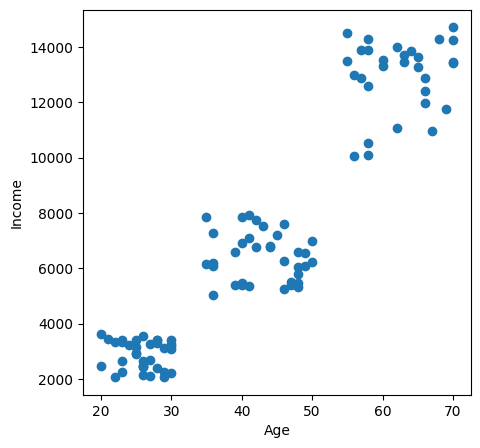

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.scatter(
    df["Age"],
    df["Income"]
)

plt.xlabel("Age")
plt.ylabel("Income")

plt.show() # 3개의 그룹으로 보임 30대미만의 저소득 그룹, 중년 중소득 그룹, 고령 고소득 그룹

In [ ]:
from sklearn.cluster import KMeans

# 비지도학습은 정답 없이 데이터의 패턴을 찾는 방법이고,
# KMeans는 데이터를 비슷한 것끼리 K개의 그룹으로 묶을 때 사용하는 대표적인 클러스터링 알고리즘이다.

X = df[["Age", "Income"]]

model = KMeans(
    n_clusters=3, # 몇 개의 그룹(클러스터)으로 나눌 것인지 지정. 보통 산포도, 엘보우(Elbow) 기법, 도메인 지식을 통해 결정
    random_state=42 # KMeans는 초기 중심점을 랜덤하게 선택하므로 같은 결과를 재현하기 위해 고정값(아무 숫자) 사용
)

model.fit(X)

# [참고] 이 셀에서 UnicodeDecodeError(cp949 codec can't decode ...)가 났던 이유
# - 에러의 원인은 내 코드가 아니다. model.fit(X) 학습 자체는 정상적으로 끝났다.
# - 문제는 model.fit(X)이 셀의 마지막 줄이라, 주피터가 학습된 모델을
#   "예쁜 박스 다이어그램(HTML)"으로 화면에 그려주려고 시도하는 과정에서 발생했다.
# - 그 다이어그램을 만들려면 sklearn이 내부적으로 estimator.js 파일을 open()으로 읽는데,
#   이 파일은 UTF-8로 저장돼 있지만 한국어 윈도우는 파일을 읽을 때 기본 인코딩이 cp949다.
# - 그래서 UTF-8 글자를 cp949 규칙으로 잘못 해석하다가 0xe2 바이트에서 디코딩에 실패한 것.
# - 즉, "한국어 윈도우 + sklearn 다이어그램 표시"가 부딪혀 생기는 환경 문제이며,
#   학습 결과(model.labels_, model.predict 등)에는 아무 영향이 없다.

In [6]:
pred = model.predict(X)

print(pred)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [7]:
df["cluster"] = pred

df

,Age,Income,cluster
0,28,2387,2
1,30,3271,2
2,29,3121,2
3,25,2957,2
4,22,3321,2
...,...,...,...
95,55,14483,1
96,58,10079,1
97,57,13889,1
98,60,13506,1


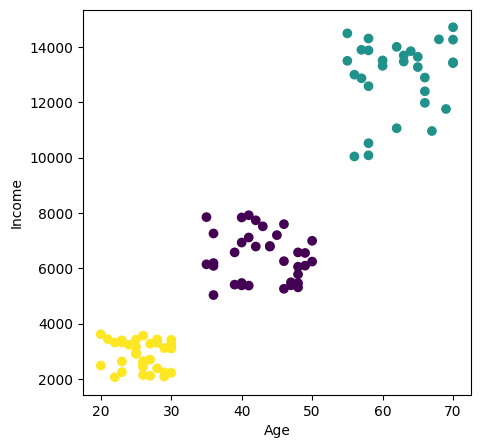

In [8]:
plt.figure(figsize=(5,5))

plt.scatter(
    df["Age"],
    df["Income"],
    c=df["cluster"]
)

plt.xlabel("Age")
plt.ylabel("Income")

plt.show()

In [9]:
print(model.cluster_centers_)
# 클러스터0 중심 
# 나이 38세
# 연봉 6750

# 클러스터1 중심
# 나이 24세
# 연봉 2950

# 클러스터2 중심
# 나이 58세
# 연봉 12875

[[   43.          6413.11428571]
 [   62.4        12963.4       ]
 [   25.91428571  2894.02857143]]


In [10]:
new_customer = pd.DataFrame(
    [[45, 8000]],
    columns=["Age", "Income"]
)

pred = model.predict(new_customer)

print(pred) # 0 그룹이면 차트에서 보라색 그룹

[0]
